In [1]:
# Imports
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [2]:
# Batting and pitching dataset with teams
df = pd.read_csv('batting_pitching_combined.csv', delimiter=',')

In [3]:
# list and drop columns that are less related to the target
cols_to_drop = ['team_old', 'league_team', 'name', 'playerid', 'mlbamid', 'team', 'Acronym', 'Full Name_team', 'Full Team Name', 'Drafted By', 'Drafted From', 'team_new', 'division_team', 'id_team', 'team_teamstats', 'Difference_team', 'conf_national_rec_team']
df = df.drop(columns=cols_to_drop)
print(df.columns.tolist())

# convert the target to numerical values
df['Drafted?'] = df['Drafted?'].astype(int)

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

In [4]:
pd.options.display.max_columns = None
df.head(10)

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team
0,19.0,A.J. Causey,2022,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,48.1,202.0,37.0,16.0,14.0,1.0,10.0,12.0,0.0,0.0,58.0,10.800000,1.862069,5.800000,0.186207,0.287129,0.049505,0.237624,0.205556,0.972414,0.297521,0.746528,3.307114,-0.700218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.4933,15,0.4720,27.0,28.0,0.0,55.0,0.491,0.509,218.0,1865.0,498.0,0.267,50.0,0.91,104.0,1.89,487.2,317.0,263.0,4.85,1463.0,591.0,59.0,0.972,64.0,66.0,530.0,9.78,61.0,1.11,16.0,22.0,0.361,33.0,0.60,17.0,323.0,5.9,NaN,805.0,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52
1,20.0,A.J. Causey,2023,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,76.1,342.0,82.0,48.0,43.0,12.0,23.0,14.0,7.0,0.0,89.0,10.493449,2.711790,3.869565,1.414847,0.260234,0.067251,0.192982,0.268852,1.375546,0.343137,0.694716,5.437457,-0.367588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.4843,17,0.4415,27.0,30.0,0.0,57.0,0.474,0.534,218.0,2004.0,602.0,0.300,37.0,0.65,115.0,2.02,483.2,376.0,331.0,6.16,1451.0,512.0,52.0,0.974,66.0,72.0,518.0,9.64,74.0,1.30,16.0,10.0,0.386,36.0,0.63,10.0,405.0,7.1,2.0,965.0,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04
3,20.0,A.J. Colarusso,2024,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,65.0,308.0,83.0,57.0,52.0,11.0,32.0,6.0,3.0,0.0,63.0,8.723077,4.430769,1.968750,1.523077,0.204545,0.103896,0.100649,0.307407,1.769231,0.367347,0.606061,5.780531,1.419469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.5686,2,0.7685,22.0,31.0,0.0,53.0,0.415,0.450,258.0,1737.0,466.0,0.268,43.0,0.81,85.0,1.60,459.0,379.0,338.0,6.63,1377.0,470.0,41.0,0.978,64.0,62.0,538.0,10.55,55.0,1.04,19.0,42.0,0.379,81.0,1.53,21.0,340.0,6.4,1.0,734.0,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73
4,21.0,A.J. Colarusso,2025,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,73.2,327.0,79.0,43.0,40.0,7.0,31.0,5.0,2.0,0.0,58.0,7.085973,3.787330,1.870968,0.855204,0.177370,0.094801,0.082569,0.271478,1.493213,0.318584,0.684411,4.940927,-0.054049,NaN,NaN,NaN,Na

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16728 entries, 0 to 16727
Columns: 123 entries, age to BBPG (Pitching)_team
dtypes: float64(118), int64(3), object(2)
memory usage: 15.7+ MB


In [6]:
player_features = list(df[['age', 'role', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 
                           'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 
                           'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 
                           'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 
                           'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 
                           'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 
                           'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 
                           'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 
                           'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 
                           'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 
                           'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat']].columns)

team_features = list(df[['conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team',
                         'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 
                         'AB_team', 'H_team', 'BA_team', 'DP_team', 'DPPG_team', '2B_team', '2BPG_team', 
                         'IP_team', 'R (Pitching)_team', 'ER_team', 'ERA_team', 'PO_team', 'A_team', 
                         'E_team', 'FPCT_team', 'HB_team', 'HBP_team', 'HA_team', 'HAPG_team', 'HR_team', 
                         'HRPG_team', 'SF_team', 'SH_team', 'OBP_team', 'SB_team', 'SBPG_team', 'CS_team', 
                         'R (Batting)_team', 'RPG_team', 'SHO_team', 'TB_team', 'SLG_team', 'SO_team', 
                         'BB (Pitching)_team', 'K/BB_team', 'K/9_team', 'TP_team', '3B_team', '3BPG_team', 
                         'WHIP_team', 'BBPG (Pitching)_team']].columns)

redundant_features = ['']

# IGNORE
#lasso_selected_features = [
#    'age', 'fip', 'K/9', 'WHIP', 'so', 'g', 'L', 'hr/9', 'wp', 'l', 'ER',
#    'HRPG', 'SF', 'babip', 'SHO', 'A', 'bk', 'BB (Pitching)', 'PE', '3B',
#    'ip', 'FPCT', 'CS', 'w', 'HB', 'DPPG', 'SH', 'T', 'SO', 'BBPG (Pitching)',
#    'SBPG', 'cg', 'RPG', 'k-bb%', 'HBP', '2BPG', 'sho', 'e-f', 'lob%', 'sv', 'E'
#]
# lasso_selected_features = [f for f in lasso_selected_features if f not in redundant_features]
#features = lasso_selected_features

features = player_features + team_features
features = [f for f in features if f not in redundant_features]
mapping = {
    'Pitcher': 0,
    'Batter': 1,
    'Both': 2
}

df['role'] = df['role'].map(mapping)

X = df[features]
y = df['Drafted?'].astype(int)

In [7]:
X.head(10)

,age,role,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team
0,19.0,0.0,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,48.1,202.0,37.0,16.0,14.0,1.0,10.0,12.0,0.0,0.0,58.0,10.800000,1.862069,5.800000,0.186207,0.287129,0.049505,0.237624,0.205556,0.972414,0.297521,0.746528,3.307114,-0.700218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4933,15,0.4720,27.0,28.0,0.0,55.0,0.491,0.509,218.0,1865.0,498.0,0.267,50.0,0.91,104.0,1.89,487.2,317.0,263.0,4.85,1463.0,591.0,59.0,0.972,64.0,66.0,530.0,9.78,61.0,1.11,16.0,22.0,0.361,33.0,0.60,17.0,323.0,5.9,NaN,805.0,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52
1,20.0,0.0,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,76.1,342.0,82.0,48.0,43.0,12.0,23.0,14.0,7.0,0.0,89.0,10.493449,2.711790,3.869565,1.414847,0.260234,0.067251,0.192982,0.268852,1.375546,0.343137,0.694716,5.437457,-0.367588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4843,17,0.4415,27.0,30.0,0.0,57.0,0.474,0.534,218.0,2004.0,602.0,0.300,37.0,0.65,115.0,2.02,483.2,376.0,331.0,6.16,1451.0,512.0,52.0,0.974,66.0,72.0,518.0,9.64,74.0,1.30,16.0,10.0,0.386,36.0,0.63,10.0,405.0,7.1,2.0,965.0,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78
2,21.0,0.0,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04
3,20.0,0.0,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,65.0,308.0,83.0,57.0,52.0,11.0,32.0,6.0,3.0,0.0,63.0,8.723077,4.430769,1.968750,1.523077,0.204545,0.103896,0.100649,0.307407,1.769231,0.367347,0.606061,5.780531,1.419469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5686,2,0.7685,22.0,31.0,0.0,53.0,0.415,0.450,258.0,1737.0,466.0,0.268,43.0,0.81,85.0,1.60,459.0,379.0,338.0,6.63,1377.0,470.0,41.0,0.978,64.0,62.0,538.0,10.55,55.0,1.04,19.0,42.0,0.379,81.0,1.53,21.0,340.0,6.4,1.0,734.0,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73
4,21.0,0.0,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,73.2,327.0,79.0,43.0,40.0,7.0,31.0,5.0,2.0,0.0,58.0,7.085973,3.787330,1.870968,0.855204,0.177370,0.094801,0.082569,0.271478,1.493213,0.318584,0.684411,4.940927,-0.054049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5673,3,0.7660,28.0,29.0,0.0,57.0,0.491,0.477,259.0,1837.0,48

In [8]:
# Separate the two classes
drafted_indices = df[df['Drafted?'] == 1].index
not_drafted_indices = df[df['Drafted?'] == 0].index

print(f"Original class distribution:")
print(f"  Class 0 (Not Drafted): {len(not_drafted_indices)}")
print(f"  Class 1 (Drafted): {len(drafted_indices)}")

# Randomly sample from class 0 to match class 1 size
np.random.seed(42)  # for reproducibility
undersampled_not_drafted = np.random.choice(not_drafted_indices, size=len(drafted_indices), replace=False)

# Combine the balanced indices
balanced_indices = np.concatenate([drafted_indices, undersampled_not_drafted])
np.random.shuffle(balanced_indices)

# Create balanced dataset
X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print(f"\nBalanced class distribution:")
print(f"  Class 0 (Not Drafted): {sum(y_balanced == 0)}")
print(f"  Class 1 (Drafted): {sum(y_balanced == 1)}")
print(f"  Total samples: {len(y_balanced)}")
print(f"  Class 1 percentage: {sum(y_balanced == 1) / len(y_balanced) * 100:.1f}%")

Original class distribution:
  Class 0 (Not Drafted): 15290
  Class 1 (Drafted): 1438

Balanced class distribution:
  Class 0 (Not Drafted): 1438
  Class 1 (Drafted): 1438
  Total samples: 2876
  Class 1 percentage: 50.0%


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

In [10]:
# Show training class distribution and compute scale_pos_weight
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count

print(f"\nTraining set distribution:")
print(f"  Class 0: {neg_count}")
print(f"  Class 1: {pos_count}")
print(f"  Scale_pos_weight: {scale_pos_weight:.2f}")


Training set distribution:
  Class 0: 1150
  Class 1: 1150
  Scale_pos_weight: 1.00


In [11]:
# Train XGBoost classifier on balanced training set
draft_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

draft_model.fit(X_train, y_train)

y_pred = draft_model.predict(X_test)
y_proba = draft_model.predict_proba(X_test)[:,1]

print("\nDrafted? Classifier Results (Balanced Dataset):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))


Drafted? Classifier Results (Balanced Dataset):
Accuracy: 0.882

              precision    recall  f1-score   support

           0      0.901     0.858     0.879       288
           1      0.864     0.906     0.885       288

    accuracy                          0.882       576
   macro avg      0.883     0.882     0.882       576
weighted avg      0.883     0.882     0.882       576



In [12]:
# Show top features by importance from the trained classifier
importance = draft_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features by Importance:")
print(importance_df.head(20))


Top 20 Features by Importance:
                   Feature  Importance
0                      age   19.835135
61                 wrc_bat   15.502576
40                   r_bat    9.130328
18                so_pitch    5.455689
110               K/9_team    4.827398
55                 slg_bat    4.789736
23                k%_pitch    4.540484
66          conf_rank_team    4.181023
67   conf_national_wp_team    3.809870
56                 ops_bat    3.792583
65           conf_rpi_team    3.397389
41                 rbi_bat    2.977838
63                woba_bat    2.725511
113              WHIP_team    2.683183
19               k/9_pitch    2.348974
30               fip_pitch    2.308756
62                wraa_bat    2.289108
52                  k%_bat    2.264633
26               avg_pitch    2.157925
1                  w_pitch    2.132744


In [13]:
# Now to set up for pick prediction among drafted players

target_drafted = 'Drafted?'
target_pick = 'Pick'
year_col = 'year'

# Keep only drafted players
drafted_df = df[df[target_drafted] == 1].copy()
pd.options.display.max_columns = None
display(drafted_df.head(5))

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04
22,22.0,Aaron Brown,2021,7.0,5.0,3.992218,14.0,14.0,3.0,0.0,0.0,85.2,348.0,67.0,38.0,38.0,13.0,15.0,7.0,4.0,0.0,113.0,11.871596,1.575876,7.533333,1.365759,0.324713,0.043103,0.281609,0.205521,0.957198,0.270000,0.720339,4.218935,-0.226717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.0,268.0,1,0.5129,6,0.5500,24.0,29.0,1.0,54.0,0.444,0.483,160.0,1634.0,397.0,0.243,42.0,0.78,86.0,1.59,442.2,247.0,206.0,4.19,1328.0,469.0,57.0,0.969,57.0,41.0,420.0,8.54,34.0,0.63,22.0,29.0,0.322,107.0,1.98,40.0,238.0,4.4,5.0,597.0,0.365,431.0,119.0,3.62,8.8,NaN,6.0,0.11,1.22,NaN
32,20.0,Aaron Davenport,2021,3.0,6.0,3.738462,13.0,13.0,0.0,0.0,0.0,86.2,358.0,82.0,41.0,36.0,6.0,21.0,6.0,5.0,0.0,97.0,10.073077,2.180769,4.619048,0.623077,0.270950,0.058659,0.212290,0.247734,1.188462,0.333333,0.675944,3.634592,0.103869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,186.0,1,0.4919,14,0.4380,24.0,26.0,0.0,50.0,0.480,0.530,170.0,1669.0,469.0,0.281,37.0,0.74,84.0,1.68,431.0,250.0,201.0,4.20,1293.0,500.0,66.0,0.964,46.0,66.0,482.0,10.06,24.0,0.48,19.0,30.0,0.366,34.0,0.68,17.0,267.0,5.3,4.0,645.0,0.386,358.0,127.0,2.82,7.5,NaN,10.0,0.20,1.41,NaN
47,21.0,Aaron McKeithan,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,180.0,221.0,50.0,35.0,12.0,0.0,3.0,35.0,24.0,26.0,20.0,12.0,3.0,0.0,10.0,2.0,1.0,0.277778,0.117647,0.090498,1.3,0.39819,0.394444,0.792634,0.116667,3.689838,0.29375,-0.168267,37.26055,1.809693,0.377073,105.104793,1.0,16.0,481.0,1,0.5129,6,0.5500,40.0,21.0,0.0,61.0,0.656,0.594,218.0,1997.0,594.0,0.297,39.0,0.64,130.0,2.13,504.2,339.0,301.0,5.37,1514.0,484.0,58.0,0.972,81.0,47.0,480.0,8.56,66.0,1.08,26.0,11.0,0.375,68.0,1.11,17.0,417.0,6.8,3.0,940.0,0.471,557.0,280.0,1.99,9.9,NaN,9.0,0.15,1.51,NaN
59,20.0,Aaron Savary,2025,7.0,2.0,4.369294,15.0,15.0,0.0,0.0,0.0,80.1,342.0,67.0,39.0,39.0,10.0,33.0,15.0,1.0,2.0,82.0,9.186722,3.697095,2.484848,1.120332,0.239766,0.096491,0.143275,0.227891,1.244813,0.282178,0.752475,5.206807,-0.837512,NaN,NaN,NaN,NaN,

In [14]:
import json
import os
from difflib import SequenceMatcher

def load_draft_jsons(json_dir: str) -> pd.DataFrame:
    """Load all mlb_draft_YYYY.json files and flatten into a DataFrame."""
    rows = []
    for fname in sorted(os.listdir(json_dir)):
        if not fname.endswith(".json"):
            continue
        print(f"  Loading {fname}...")
        with open(os.path.join(json_dir, fname), "r", encoding="utf-8") as f:
            data = json.load(f)

        draft_year = data.get("drafts", {}).get("draftYear")
        if draft_year is None:
            print(f"    ⚠️ No draftYear found, skipping")
            continue

        for rd in data.get("drafts", {}).get("rounds", []):
            for pick in rd.get("picks", []):
                person = pick.get("person", {}) or {}
                pos = person.get("primaryPosition", {}) or {}
                bat = person.get("batSide", {}) or {}
                pitch = person.get("pitchHand", {}) or {}

                ov = pick.get("pickOverall") or pick.get("displayPickNumber")

                rows.append({
                    "year": int(draft_year),
                    "Pick": float(ov) if ov else None,
                    "api_name": person.get("fullName"),
                    "api_batSide": bat.get("code"),
                    "api_pitchHand": pitch.get("code"),
                    "api_primaryPos": pos.get("abbreviation"),
                    "api_weight": person.get("weight"),
                    "api_height": person.get("height"),
                    "api_pickValue": float(pick["pickValue"]) / 1e6 if pick.get("pickValue") else None,
                    "api_signingBonus": float(pick["signingBonus"]) / 1e6 if pick.get("signingBonus") else None,
                })

    df = pd.DataFrame(rows)
    if df.empty:
        print("⚠️ No picks loaded! Check your JSON_DIR path and file contents.")
        return df
    return df.drop_duplicates(subset=["year", "Pick"])


def name_similarity(a, b) -> float:
    if pd.isna(a) or pd.isna(b):
        return 0.0
    return round(SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio() * 100, 1)


def height_to_inches(h):
    if pd.isna(h):
        return None
    try:
        parts = str(h).replace('"', '').split("'")
        return int(parts[0].strip()) * 12 + int(parts[1].strip())
    except (ValueError, IndexError):
        return None


# ── Load JSONs ────────────────────────────────────────────────────────
JSON_DIR = "./For Mateo-MLBStatsAPIDraftDataAccess"

print(f"Looking in: {os.path.abspath(JSON_DIR)}")
print(f"Files found: {os.listdir(JSON_DIR)}\n")

api_df = load_draft_jsons(JSON_DIR)

print(f"\nAPI data: {len(api_df)} picks across years {sorted(api_df['year'].unique()) if not api_df.empty else 'NONE'}")
print(f"Drafted data: {len(drafted_df)} rows, Pick dtype={drafted_df['Pick'].dtype}, year dtype={drafted_df['year'].dtype}")

# ── Print unique string values before mapping ─────────────────────────
print(f"\nUnique api_batSide values:   {sorted(api_df['api_batSide'].dropna().unique())}")
print(f"Unique api_pitchHand values: {sorted(api_df['api_pitchHand'].dropna().unique())}")
print(f"Unique api_primaryPos values: {sorted(api_df['api_primaryPos'].dropna().unique())}")
print(f"Unique api_height values:    {sorted(api_df['api_height'].dropna().unique())}")

# ── Ensure matching dtypes ────────────────────────────────────────────
drafted_df["Pick"] = drafted_df["Pick"].astype(float)
drafted_df["year"] = drafted_df["year"].astype(int)

if not api_df.empty:
    api_df["Pick"] = api_df["Pick"].astype(float)
    api_df["year"] = api_df["year"].astype(int)

    # Spot check: do the keys overlap?
    draft_keys = set(zip(drafted_df["year"], drafted_df["Pick"]))
    api_keys = set(zip(api_df["year"], api_df["Pick"]))
    overlap = draft_keys & api_keys
    print(f"\nKey overlap: {len(overlap)} matches out of {len(draft_keys)} drafted rows")

    # Merge
    drafted_df = drafted_df.merge(api_df, on=["year", "Pick"], how="left")

    # Name match
    drafted_df["name_match_pct"] = drafted_df.apply(
        lambda r: name_similarity(r["nameascii"], r["api_name"]), axis=1
    )

    print(f"\nMatched: {drafted_df['api_name'].notna().sum()} / {len(drafted_df)}")

    # Drop bad matches
    MATCH_THRESHOLD = 70
    low_match = drafted_df[drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)]
    if len(low_match) > 0:
        print(f"\n⚠️ Dropping {len(low_match)} rows with name match < {MATCH_THRESHOLD}%:")
        print(low_match[["year", "Pick", "nameascii", "api_name", "name_match_pct"]].to_string(index=False))

    drafted_df = drafted_df[~drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)].copy()
    print(f"\nRows remaining: {len(drafted_df)}")

    # ── Encode string columns to numeric ──────────────────────────────
    bat_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_batSide"] = drafted_df["api_batSide"].map(bat_map)

    pitch_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_pitchHand"] = drafted_df["api_pitchHand"].map(pitch_map)

    pos_map = {
        "C": 1, "SS": 2, "2B": 3, "3B": 4, "CF": 5,
        "LF": 6, "RF": 7, "IF": 8, "1B": 9, "OF": 10, "DH": 11,
        "P": 12, "TWP": 13,
    }
    drafted_df["api_primaryPos"] = drafted_df["api_primaryPos"].map(pos_map)

    drafted_df["api_height"] = drafted_df["api_height"].apply(height_to_inches).astype(float)

    # Verify
    print("\nConverted dtypes:")
    for col in ["api_batSide", "api_pitchHand", "api_primaryPos", "api_height", "api_weight"]:
        print(f"  {col}: {drafted_df[col].dtype}, unique: {sorted(drafted_df[col].dropna().unique())}")

else:
    print("\n❌ No API data loaded — nothing to merge.")

Looking in: c:\Users\mateo\ncaaBaseballDraft-Predictor\CSV+Code Files\trial_xgBoost\For Mateo-MLBStatsAPIDraftDataAccess
Files found: ['enrich_draft_data.py', 'enrich_draft_dataV2.py', 'statsapi_draft_2021.json', 'statsapi_draft_2022.json', 'statsapi_draft_2023.json', 'statsapi_draft_2024.json', 'statsapi_draft_2025.json', 'statsapi_teams.json']

  Loading statsapi_draft_2021.json...
  Loading statsapi_draft_2022.json...
  Loading statsapi_draft_2023.json...
  Loading statsapi_draft_2024.json...
  Loading statsapi_draft_2025.json...
  Loading statsapi_teams.json...
    ⚠️ No draftYear found, skipping

API data: 3072 picks across years [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Drafted data: 1438 rows, Pick dtype=float64, year dtype=int64

Unique api_batSide values:   ['L', 'R', 'S']
Unique api_pitchHand values: ['L', 'R', 'S']
Unique api_primaryPos values: ['1B', '2B', '3B', 'C', 'CF', 'IF', 'LF', 'OF', 'P', 'RF', 'SS', 'TWP']
Unique api_height val

In [15]:
draftedClean_df = drafted_df.drop(columns=['api_name', 'name_match_pct'])

print(draftedClean_df.columns.tolist())
display(draftedClean_df.head(10))

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,api_batSide,api_pitchHand,api_primaryPos,api_weight,api_height,api_pickValue,api_signingBonus
0,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0,0,12,210,75.0,0.5050,0.4775
1,22.0,Aaron Brown,2021,7.0,5.0,3.992218,14.0,14.0,3.0,0.0,0.0,85.2,348.0,67.0,38.0,38.0,13.0,15.0,7.0,4.0,0.0,113.0,11.871596,1.575876,7.533333,1.365759,0.324713,0.043103,0.281609,0.205521,0.957198,0.270000,0.720339,4.218935,-0.226717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.0,268.0,1,0.5129,6,0.5500,24.0,29.0,1.0,54.0,0.444,0.483,160.0,1634.0,397.0,0.243,42.0,0.78,86.0,1.59,442.2,247.0,206.0,4.19,1328.0,469.0,57.0,0.969,57.0,41.0,420.0,8.54,34.0,0.63,22.0,29.0,0.322,107.0,1.98,40.0,238.0,4.4,5.0,597.0,0.365,431.0,119.0,3.62,8.8,NaN,6.0,0.11,1.22,NaN,0,0,12,220,76.0,0.1546,0.0575
2,20.0,Aaron Davenport,2021,3.0,6.0,3.738462,13.0,13.0,0.0,0.0,0.0,86.2,358.0,82.0,41.0,36.0,6.0,21.0,6.0,5.0,0.0,97.0,10.073077,2.180769,4.619048,0.623077,0.270950,0.058659,0.212290,0.247734,1.188462,0.333333,0.675944,3.634592,0.103869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,186.0,1,0.4919,14,0.4380,24.0,26.0,0.0,50.0,0.480,0.530,170.0,1669.0,469.0,0.281,37.0,0.74,84.0,1.68,431.0,250.0,201.0,4.20,1293.0,500.0,66.0,0.964,46.0,66.0,482.0,10.06,24.0,0.48,19.0,30.0,0.366,34.0,0.68,17.0,267.0,5.3,4.0,645.0,0.386,358.0,127.0,2.82,7.5,NaN,10.0,0.20,1.41,NaN,0,0,12,185,72.0,0.2594,0.4500
3,21.0,Aaron McKeithan,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,180.0,221.0,50.0,35.0,12.0,0.0,3.0,35.0,24.0,26.0,20.0,12.0,3.0,0.0,10.0,2.0,1.0,0.277778,0.117647,0.090498,1.300000,0.398190,0.394444,0.792634,0.116667,3.689838,0.293750,-0.168267,37.260550,1.809693,0.377073,105.104793,1.0,16.0,481.0,1,0.5129,6,0.5500,40.0,21.0,0.0,61.0,0.656,0.594,218.0,1997.0,594.0,0.297,39.0,0.64,130.0,2.13,504.2,339.0,301.0,5.37,1514.0,484.0,58.0,0.972,81.0,47.0,480.0,8.56,66.0,1.08,26.0,11.0,0.375,68.0,1.11,17.0,417.0,6.8,3.0,940.0,0.471,557.0,280.0,1.99,9.9,NaN,9.0,0.15,1.51,NaN,0,0,1,225,71.0,NaN,0.0500
4,20.0,Aaron Savary,2025,7.0,2.0,4.369

In [16]:
# Create college-only rank as target for each year
# Filter to college players only and rank within each year
draftedClean_df = drafted_df[drafted_df[target_drafted] == 1].copy()

# Create college-only draft order within each year
draftedClean_df = draftedClean_df.sort_values([year_col, target_pick])
draftedClean_df['College_Draft_Order'] = draftedClean_df.groupby(year_col).cumcount() + 1

# Normalize to 0-1 so rankings are comparable across years with different class sizes
draftedClean_df['College_Draft_Pct'] = draftedClean_df.groupby(year_col)['College_Draft_Order'].transform(
    lambda x: (x - 1) / (len(x) - 1) if len(x) > 1 else 0.5
)

print("College draft order examples:")
print(draftedClean_df[[year_col, 'nameascii', target_pick, 'College_Draft_Order', 'College_Draft_Pct']].head(15))
print(f"\nPlayers per year:")
print(draftedClean_df.groupby(year_col).size())

College draft order examples:
      year         nameascii  Pick  College_Draft_Order  College_Draft_Pct
592   2021       Henry Davis   1.0                    1           0.000000
644   2021       Jack Leiter   2.0                    2           0.003484
379   2021     Colton Cowser   5.0                    3           0.006969
1229  2021       Sam Bachman   9.0                    4           0.010453
902   2021      Kumar Rocker  10.0                    5           0.013937
1384  2021       Will Bednar  14.0                    6           0.017422
1226  2021       Sal Frelick  15.0                    7           0.020906
1035  2021  Michael McGreevy  18.0                    8           0.024390
579   2021    Gunnar Hoglund  19.0                    9           0.027875
1338  2021      Trey Sweeney  20.0                   10           0.031359
562   2021    Gavin Williams  23.0                   11           0.034843
1197  2021       Ryan Cusick  24.0                   12           0.03

In [17]:
# XGBoost regression to predict college draft order, using just College_Draft_Order as target (not pick number)

test_year = draftedClean_df[year_col].max()

train_df = draftedClean_df[draftedClean_df[year_col] < test_year]
test_df  = draftedClean_df[draftedClean_df[year_col] == test_year]

api_features = ['api_batSide', 'api_pitchHand', 'api_primaryPos', 'api_weight', 'api_height']
all_features = features + api_features

pick_features = [f for f in all_features if f not in redundant_features]

print(train_df.columns.tolist())
X_train = train_df[pick_features]
y_train = train_df['College_Draft_Order']

X_test = test_df[pick_features]
y_test_order = test_df['College_Draft_Order']

model_rank = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

model_rank.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test_order)],
    verbose=50
)

preds = model_rank.predict(X_test)
pred_order = pd.Series(preds).rank(method='min').astype(int).values
actual_order = y_test_order.values

print(f"College draft class sizes per year:")
print(draftedClean_df.groupby(year_col).size())

corr_order, p_value = spearmanr(actual_order, pred_order)
mae_order = mean_absolute_error(actual_order, pred_order)

print(f"\nCollege-Only Rank Model — Raw Order Target (n={len(y_test_order)}):")
print(f"  Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"  MAE:      {mae_order:.1f}")

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

In [18]:
corr_order, p_value = spearmanr(actual_order, pred_order)

# Fisher z-transform for confidence interval
n = len(actual_order)
z = np.arctanh(corr_order)
se = 1 / np.sqrt(n - 3)
alpha = 0.05
z_crit = 1.96  # for 95% CI

ci_low = np.tanh(z - z_crit * se)
ci_high = np.tanh(z + z_crit * se)

print(f"Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"95% CI:   [{ci_low:.3f}, {ci_high:.3f}]")

Spearman: 0.693 (p=1.80e-40)
95% CI:   [0.625, 0.750]


In [19]:
# Show top features by importance from the trained classifier
importance = model_rank.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(120))


All Features by Importance:
                   Feature     Importance
0                      age  111753.023438
25             k-bb%_pitch   96245.382812
61                 wrc_bat   86658.507812
18                so_pitch   77957.140625
107                SO_team   70463.468750
66          conf_rank_team   62787.992188
27              whip_pitch   50780.781250
62                wraa_bat   50292.832031
5                 gs_pitch   46093.070312
65           conf_rpi_team   45533.273438
67   conf_national_wp_team   45366.289062
53                bb/k_bat   44336.335938
56                 ops_bat   41199.097656
55                 slg_bat   38226.453125
39                  hr_bat   36935.667969
40                   r_bat   33937.531250
21              k/bb_pitch   33734.640625
23                k%_pitch   33646.281250
30               fip_pitch   28706.916016
46                  sh_bat   28546.099609
64                wrc+_bat   28146.000000
110               K/9_team   27715.376953
42   

In [ ]:
# Build results dataframe
results_rank_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_College_Order': pred_order,
    'Actual_College_Order': actual_order,
})

results_rank_df = results_rank_df.sort_values('Actual_College_Order').reset_index(drop=True)

print(f"Player College Draft Order Predictions (Test Year: {test_year})")
print(f"Total college draftees: {len(results_rank_df)}\n")
display(results_rank_df.head(20))

Player College Draft Order Predictions (Test Year: 2025)
Total college draftees: 274



,name,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,3,1
1,Liam Doyle,2,2
2,Aiva Arquette,6,3
3,Jamie Arnold,4,4
4,Gavin Kilen,17,5
5,Kyson Witherspoon,8,6
6,Marek Houston,13,7
7,Ike Irish,7,8
8,Andrew Fischer,1,9
9,Jace LaViolette,32,10


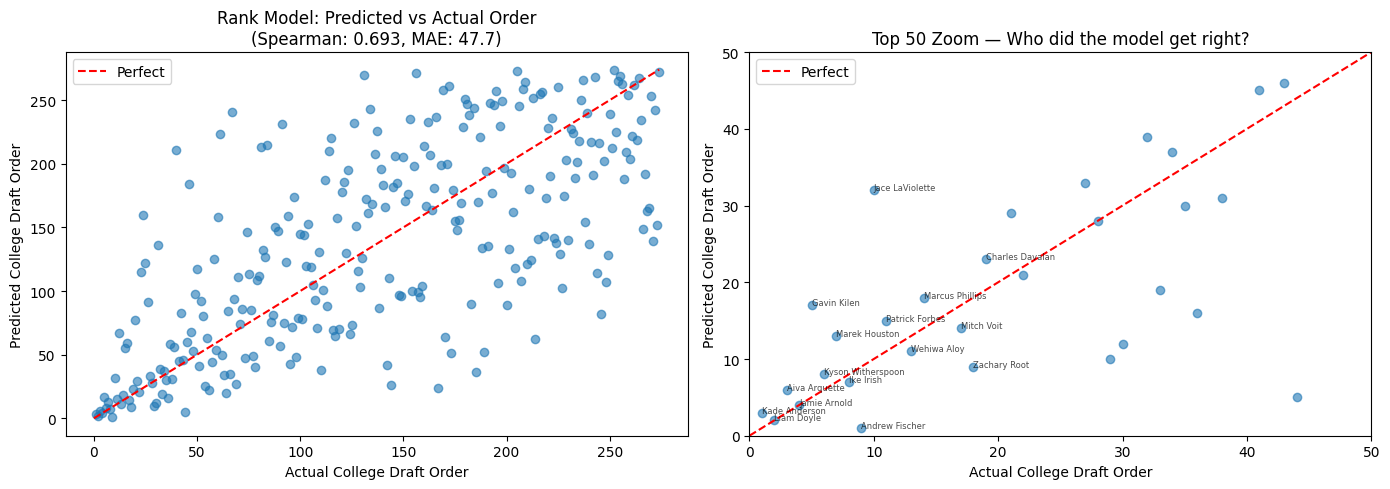

In [21]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_test = len(actual_order)

axes[0].scatter(actual_order, pred_order, alpha=0.6)
axes[0].plot([0, n_test], [0, n_test], 'r--', label='Perfect')
axes[0].set_xlabel('Actual College Draft Order')
axes[0].set_ylabel('Predicted College Draft Order')
axes[0].set_title(f'Rank Model: Predicted vs Actual Order\n(Spearman: {corr_order:.3f}, MAE: {mae_order:.1f})')
axes[0].legend()

axes[1].scatter(actual_order, pred_order, alpha=0.6)
# Add player labels for top 20
for _, row in results_rank_df.head(20).iterrows():
    if row['Actual_College_Order'] <= 20 or row['Predicted_College_Order'] <= 20:
        axes[1].annotate(row['name'], (row['Actual_College_Order'], row['Predicted_College_Order']),
                         fontsize=6, alpha=0.7)
axes[1].plot([0, 50], [0, 50], 'r--', label='Perfect')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)
axes[1].set_xlabel('Actual College Draft Order')
axes[1].set_ylabel('Predicted College Draft Order')
axes[1].set_title('Top 50 Zoom — Who did the model get right?')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
prospects = pd.read_csv('mlb_2025_draft_prospects_top250.csv')

# Compare with MLB Pipeline on matched players
results_rank_df['name_clean'] = results_rank_df['name'].str.strip().str.lower()
prospects['name_clean'] = prospects['name'].str.strip().str.lower()

comp = results_rank_df.merge(prospects[['name_clean', 'rank']], on='name_clean', how='inner')

# Re-rank everything among only matched players
comp = comp.sort_values('Actual_Pick').reset_index(drop=True)
comp['Actual_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('Predicted_College_Order').reset_index(drop=True)
comp['Pred_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('rank').reset_index(drop=True)
comp['Pipeline_Order_Matched'] = range(1, len(comp) + 1)

corr_you, p_you = spearmanr(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
corr_pipe, p_pipe = spearmanr(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])
mae_you = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
mae_pipe = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])

print(f"Head-to-Head on Matched College Players (n={len(comp)})")
print(f"{'Comparison':<45} {'Spearman':>10}    {'P-Value':>8}  {'MAE':>10}")
print("-" * 80)
print(f"{'Your Rank Model vs Actual':<45} {corr_you:>10.3f}    {p_you:.2e} {mae_you:>10.1f}")
print(f"{'MLB Pipeline vs Actual':<45} {corr_pipe:>10.3f}    {p_pipe:.2e} {mae_pipe:>10.1f}")

comp = comp[['name', 'Pipeline_Order_Matched', 'Predicted_College_Order', 'Actual_College_Order']].copy()
comp.columns = ['name', 'MLB_Pipeline_College_Order', 'Predicted_College_Order', 'Actual_College_Order']
display(comp.sort_values('Actual_College_Order').reset_index(drop=True).head(25))

Head-to-Head on Matched College Players (n=98)
Comparison                                      Spearman     P-Value         MAE
--------------------------------------------------------------------------------
Your Rank Model vs Actual                          0.657    2.07e-13       17.2
MLB Pipeline vs Actual                             0.841    2.34e-27       11.3


,name,MLB_Pipeline_College_Order,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,1,3,1
1,Liam Doyle,4,2,2
2,Aiva Arquette,3,6,3
3,Jamie Arnold,2,4,4
4,Gavin Kilen,11,17,5
5,Kyson Witherspoon,5,8,6
6,Marek Houston,7,13,7
7,Ike Irish,6,7,8
8,Andrew Fischer,12,1,9
9,Jace LaViolette,10,32,10


In [23]:
# Show top features with missing values
missing_summary = X.isnull().mean().sort_values(ascending=False)
print(missing_summary[missing_summary > 0].head(15))

TP_team      0.980332
l_pitch      0.670612
era_pitch    0.670612
g_pitch      0.670612
cg_pitch     0.670612
w_pitch      0.670612
er_pitch     0.670612
hr_pitch     0.670612
sho_pitch    0.670612
sv_pitch     0.670612
ip_pitch     0.670612
tbf_pitch    0.670612
h_pitch      0.670612
r_pitch      0.670612
wp_pitch     0.670612
dtype: float64
